# Geospatial Clustering for Competitive Analysis

This notebook builds a location-based clustering pipeline and derives competitive benchmarks for Airbnb listings.

## Outputs
- Geospatial cluster assignments
- Cluster-level benchmark table
- Cluster model artifact for API usage

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [12]:
project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

data_path = project_root / "data" / "processed" / "main" / "feature_engineered.csv"
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

df = pd.read_csv(data_path)
print(f"Loaded: {data_path}")
print(f"Shape: {df.shape}")

Loaded: c:\Users\RUSHIKESH\Desktop\Airbnb Project\data\processed\main\feature_engineered.csv
Shape: (37293, 62)


In [13]:
required_cols = [
    "latitude",
    "longitude",
    "ttm_avg_rate",
    "avg_rating",
    "num_reviews",
    "total_amenities",
    "luxury_score",
    "rarity_score",
    "comfort_to_total_ratio",
]

optional_cols = [
    "basic_count",
    "comfort_count",
    "kitchen_count",
    "safety_count",
    "outdoor_count",
    "family_count",
    "services_count",
    "has_pool",
    "has_hot_tub",
    "has_gym",
    "has_beach_access",
    "has_dedicated_workspace",
    "has_pets_allowed",
    "has_free_parking_on_premises",
    "has_air_conditioning",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

available_optional = [c for c in optional_cols if c in df.columns]
cluster_df = df[required_cols + available_optional].copy()
cluster_df = cluster_df.dropna(subset=["latitude", "longitude", "ttm_avg_rate"])

# Stored target is log-space; convert for business-level competitive benchmarks.
cluster_df["ttm_avg_rate_business"] = np.maximum(np.expm1(cluster_df["ttm_avg_rate"].astype(float)), 0.0)

# Clustering-friendly engineered features from amenities and engagement.
cluster_df["reviews_log"] = np.log1p(np.clip(cluster_df["num_reviews"], a_min=0, a_max=None))
cluster_df["amenity_premium_index"] = cluster_df["luxury_score"].fillna(0) + cluster_df["rarity_score"].fillna(0)

count_cols = [c for c in ["basic_count", "comfort_count", "kitchen_count", "safety_count", "outdoor_count", "family_count", "services_count"] if c in cluster_df.columns]
if count_cols:
    cluster_df["amenity_utility_index"] = cluster_df[count_cols].sum(axis=1)
else:
    cluster_df["amenity_utility_index"] = cluster_df["total_amenities"].fillna(0)

flag_cols = [c for c in [
    "has_pool",
    "has_hot_tub",
    "has_gym",
    "has_beach_access",
    "has_dedicated_workspace",
    "has_pets_allowed",
    "has_free_parking_on_premises",
    "has_air_conditioning",
] if c in cluster_df.columns]
if flag_cols:
    cluster_df["amenity_binary_sum"] = cluster_df[flag_cols].sum(axis=1)
else:
    cluster_df["amenity_binary_sum"] = 0

cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan).dropna()

print("Using columns for clustering + profiling:")
print(cluster_df.columns.tolist())
print(cluster_df.describe().T)

Using columns for clustering + profiling:
['latitude', 'longitude', 'ttm_avg_rate', 'avg_rating', 'num_reviews', 'total_amenities', 'luxury_score', 'rarity_score', 'comfort_to_total_ratio', 'basic_count', 'comfort_count', 'kitchen_count', 'safety_count', 'outdoor_count', 'family_count', 'services_count', 'has_pool', 'has_hot_tub', 'has_gym', 'has_beach_access', 'has_dedicated_workspace', 'has_pets_allowed', 'has_free_parking_on_premises', 'has_air_conditioning', 'ttm_avg_rate_business', 'reviews_log', 'amenity_premium_index', 'amenity_utility_index', 'amenity_binary_sum']
                                count        mean         std         min  \
latitude                      37293.0   20.293610   27.398462  -45.075900   
longitude                     37293.0    3.009209   71.799065 -157.861400   
ttm_avg_rate                  37293.0    4.506853    0.812647    2.261763   
avg_rating                    37293.0    4.806135    0.153554    2.218571   
num_reviews                   37293.

In [14]:
X_geo = cluster_df[["latitude", "longitude"]].to_numpy()

candidate_k = list(range(5, 16))
scores = []
for k in candidate_k:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_geo)
    sil = silhouette_score(X_geo, labels)
    scores.append((k, sil))

scores_df = pd.DataFrame(scores, columns=["k", "silhouette"]).sort_values("silhouette", ascending=False)
best_k = int(scores_df.iloc[0]["k"])
print(scores_df.head())
print(f"Selected k: {best_k}")

    k  silhouette
1   6    0.609217
0   5    0.599708
9  14    0.569027
2   7    0.560855
7  12    0.556610
Selected k: 6


In [15]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df["cluster_id"] = kmeans.fit_predict(X_geo)

cluster_profile = (
    cluster_df.groupby("cluster_id")
    .agg(
        listings=("cluster_id", "size"),
        median_rate=("ttm_avg_rate_business", "median"),
        median_rating=("avg_rating", "median"),
        median_reviews=("num_reviews", "median"),
        median_total_amenities=("total_amenities", "median"),
        median_luxury_score=("luxury_score", "median"),
        median_rarity_score=("rarity_score", "median"),
        median_amenity_utility=("amenity_utility_index", "median"),
        median_amenity_premium=("amenity_premium_index", "median"),
        median_binary_flags=("amenity_binary_sum", "median"),
        lat_center=("latitude", "mean"),
        lon_center=("longitude", "mean"),
    )
    .reset_index()
    .sort_values("median_rate")
    .reset_index(drop=True)
)

cluster_profile

,cluster_id,listings,median_rate,median_rating,median_reviews,median_total_amenities,median_luxury_score,median_rarity_score,median_amenity_utility,median_amenity_premium,median_binary_flags,lat_center,lon_center
0,4,4402,42.10,4.856429,4.127134,31.0,2.0,0.001723,14.0,2.002660,2.0,-15.419228,-57.473354
1,3,5196,48.60,4.825000,4.330733,30.0,3.0,0.001704,14.0,3.000836,3.0,18.160096,111.098481
2,5,3341,63.60,4.851429,3.784190,36.0,4.0,0.002151,16.0,4.000766,3.0,-23.438606,27.502391
3,1,15222,111.80,4.822857,4.290459,34.0,2.0,0.001847,16.0,2.001478,2.0,39.830674,16.357400
4,2,7944,129.75,4.862857,4.912655,39.0,2.0,0.002230,18.0,2.002627,3.0,31.216014,-92.767257
5,0,1188,140.65,4.881429,4.969813,40.0,2.0,0.002299,18.0,2.002279,2.0,-38.425076,154.897028


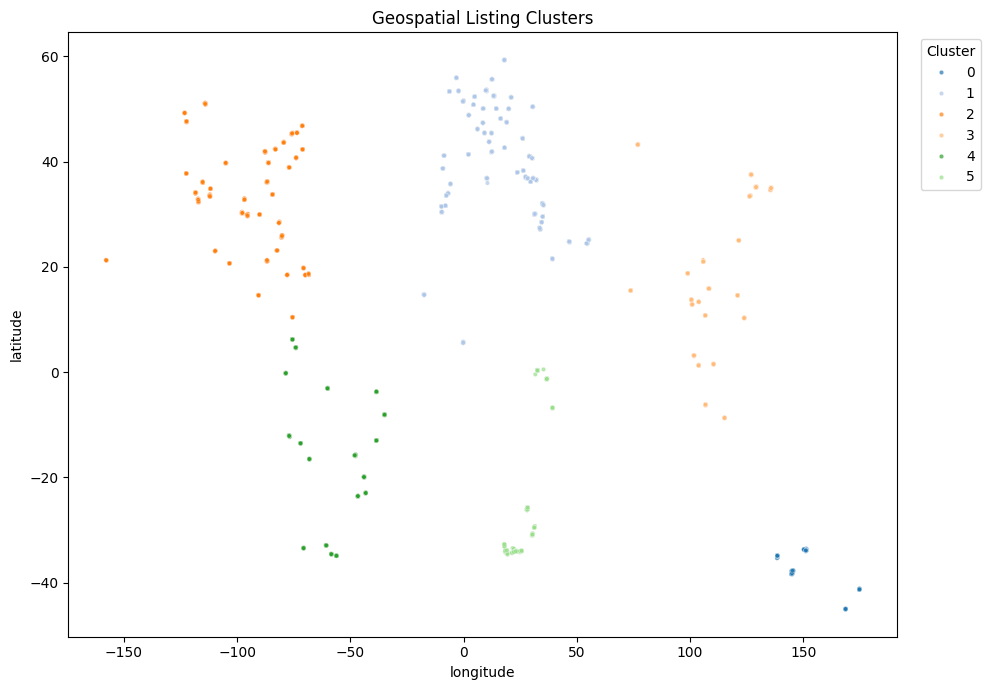

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=cluster_df.sample(min(len(cluster_df), 10000), random_state=42),
    x="longitude",
    y="latitude",
    hue="cluster_id",
    palette="tab20",
    s=10,
    alpha=0.7,
)
plt.title("Geospatial Listing Clusters")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [17]:
cluster_output_path = models_dir / "competitive_cluster_profile.csv"
kmeans_path = models_dir / "competitive_geo_kmeans.pkl"
clustered_rows_path = models_dir / "competitive_clustered_listings_sample.csv"

cluster_profile.to_csv(cluster_output_path, index=False)
joblib.dump(kmeans, kmeans_path)

# Save a light sample for debugging/QA in API and dashboard development.
cols_for_sample = [
    "latitude",
    "longitude",
    "cluster_id",
    "ttm_avg_rate_business",
    "avg_rating",
    "num_reviews",
    "total_amenities",
    "amenity_premium_index",
    "amenity_utility_index",
]
existing_sample_cols = [c for c in cols_for_sample if c in cluster_df.columns]
cluster_df[existing_sample_cols].sample(min(len(cluster_df), 10000), random_state=42).to_csv(
    clustered_rows_path, index=False
)

print(f"Saved cluster profile: {cluster_output_path}")
print(f"Saved KMeans model: {kmeans_path}")
print(f"Saved clustered sample: {clustered_rows_path}")

Saved cluster profile: c:\Users\RUSHIKESH\Desktop\Airbnb Project\models\competitive_cluster_profile.csv
Saved KMeans model: c:\Users\RUSHIKESH\Desktop\Airbnb Project\models\competitive_geo_kmeans.pkl
Saved clustered sample: c:\Users\RUSHIKESH\Desktop\Airbnb Project\models\competitive_clustered_listings_sample.csv
